In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle
import random

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=6)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:2,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:2,i_time] = maxI_
    return control_

In [105]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][:] = vars[sv]
    #setParametersALN(aln)
                    
def setParametersALN(model):
    model.params.rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
    model.params.IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
    model.params.seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
    model.params.seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
    model.params.siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
    model.params.mue_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))
    model.params.mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))

In [4]:
tol = 1e-24

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

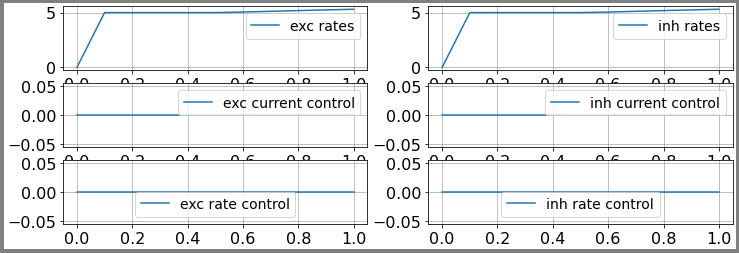

In [216]:
aln = RateModel()

aln.params['duration'] = 1.
aln.params.dt = 0.1
control0 = aln.getZeroControl()

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.
aln.params.mue_ext_mean = 0.
aln.params.mui_ext_mean = 0.
aln.params.sigmae_ext = 0.
aln.params.sigmai_ext = 0.
aln.params.ext_exc_current = 0.
aln.params.ext_inh_current = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.2
aln.params.di = 0.2

aln.params.cee = 1.
aln.params.Jee_max = 1.

aln.params.cie = 1.
aln.params.Jie_max = 1.

aln.params.cei = 1.
aln.params.Jei_max = 1.

aln.params.cii = 1.
aln.params.Jii_max = 1.

aln.params.tau_se = 1.
aln.params.tau_si = 1.
aln.params.C = 1.
aln.params.gL = 1.
aln.params.Ke = 1000.
aln.params.Ki = 1000.

setParametersALN(aln)

plotFunc.plot_traces(aln, control0)

output = aln.output_vars

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

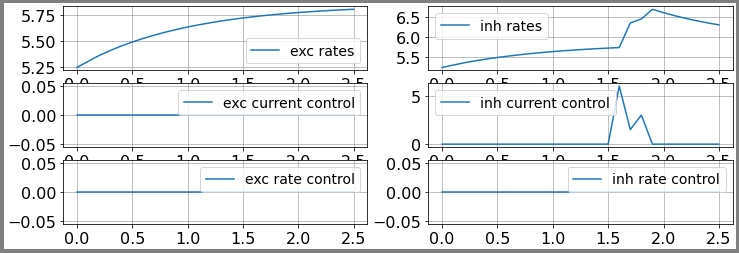

[5.49133407 5.52669406 5.55862882 5.5874891  5.61357612 5.63715667
 5.65847056 5.67773451 5.69514467 5.71087863 5.72509714 5.73794566
 6.34955579 6.45004658 6.69052568 6.60668535 6.53157373 6.46439561
 6.40458627 6.35114892 6.30319877]


In [254]:
setinitvars(high_state_vars)

dur = 2.
dur_pre = 0.5
dur_post = 0.5

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

aln.params.duration = dur + dur_pre

control_ind = [1]
prec_var = [1]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 15.
    min_cntrl = -15.
else:
    max_cntrl = 0.1
    min_cntrl = 0.

control0 = aln.getZeroControl()
#control0[0,control_ind,:] =  np.sin(np.arange(0,dur+1, 1))
#control0[0,control_ind,0] = 1.
for j in control_ind:
    #control0[0,j,n_pre + 0] = 1.0 * max_cntrl - 0.0 * min_cntrl
    #control0[0,j,n_pre + 1] = 0.4 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 10] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 11] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 12] = 0.2 * max_cntrl #+ 0.3 * min_cntrl
    #control0[0,j,n_pre + 6] = 0.2 * max_cntrl #- 0.6 * min_cntrl
    #control0[0,j,n_pre + 7] = 0.2 * max_cntrl + 0.8 * min_cntrl

plotFunc.plot_traces(aln, control0)

aln.params.duration = dur
target1 = aln.getZeroTarget()
target1[0,0,:] = aln.rates_exc[0,n_pre-1:]
target1[0,1,:] = aln.rates_inh[0,n_pre-1:]

print(target1[0,1,:])

#control1 = aln.getZeroControl()
#for k in range(1, control1.shape[2]-2):
#    control1[0,j,k] += random.uniform(0., 1.) * 0.1 * max_cntrl

In [253]:
costparams = [1. * 1e0, 1.* 1e-1, 1.* 1e-1]
#costparams = [9.9, 5., 0.]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 20
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,:] *= 1.
control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target,
        c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,n_pre-1:-n_post+1])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# -9.11609228e-02
# 0.002345565904937199

print("max grad value = ", np.amax(np.abs( grad[0,control_ind[0],:] ) ) )
#0.14002287214095344

set cost params
RUN  0 , total integrated cost =  0.21431594874482934
RUN  1 , total integrated cost =  0.14041150909181044
RUN  2 , total integrated cost =  0.13706710795608706
RUN  3 , total integrated cost =  0.13689884917636824
RUN  4 , total integrated cost =  0.13687898868830922
RUN  5 , total integrated cost =  0.1368785510344773
RUN  6 , total integrated cost =  0.1368785457913625
RUN  7 , total integrated cost =  0.13687854564386762
RUN  8 , total integrated cost =  0.13687854564245439
RUN  9 , total integrated cost =  0.13687854564241356
RUN  10 , total integrated cost =  0.13687854564241225
RUN 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 11 , total integrated cost =  0.13687854564241209
RUN  12 , total integrated cost =  0.136878545642412
RUN  13 , total integrated cost =  0.136878545642412
Control only changes marginally.
RUN  13 , total integrated cost =  0.136878545642412
Improved over  13  iterations by  36.13235671723923  percent.
Problem in initial value trasfer:  sigmae_f 0.4976603499407561 0.005009793024275202
Problem in initial value trasfer:  sigmai_f 0.31208464742010855 0.005009793024275202
Problem in initial value trasfer:  sigmae_f 0.4484940664836016 0.00414702624579349
Problem in initial value trasfer:  sigmai_f 0.2867779246620634 0.0036144984754276693
control ind  1
grad =  [ 0.00000000e+00 -3.69040733e-04 -3.90959564e-04 -3.96647580e-04
 -3.83486756e-04 -3.49600497e-04 -2.95803247e-04 -2.28603630e-04
 -1.64359328e-04 -1.40116050e-04 -2.17891961e-04 -5.02491820e-04
 -3.27535965e-04 -2.63293330e-04 -5.37763848e-05  1.41310858e-05
  1.92541310e-05  5.95010433e-06 -4.43047860e-06 -5.55217192e-06
  0.000000

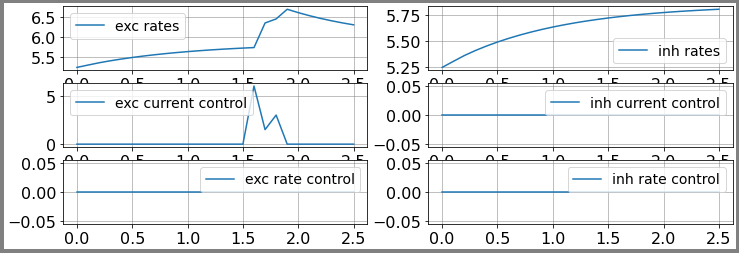

[5.49133407 5.52669406 5.55862882 5.5874891  5.61357612 5.63715667
 5.65847056 5.67773451 5.69514467 5.71087863 5.72509714 5.73794566
 5.74955579 5.76004658 5.76952568 5.77809045 5.78582891 5.79282065
 5.79913761 5.80484483 5.81000109]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


'\n[5.49133407 5.52669406 5.55862882 5.5874891  5.61357612 5.63715667\n 5.65847056 5.67773451 5.69514467 5.71087863 5.72509714 5.73794566\n 6.34955579 6.45004658 6.69052568 6.60668535 6.53157373 6.46439561\n 6.40458627 6.35114892 6.30319877]\n'

In [255]:
aln.params.duration = dur + dur_pre

control_ind = [0]
prec_var = [0]

if control_ind[0] == 0 or control_ind[0] == 1:
    max_cntrl = 15.
    min_cntrl = -15.
else:
    max_cntrl = 0.1
    min_cntrl = 0.

control0 = aln.getZeroControl()
for j in control_ind:
    control0[0,j,n_pre + 10] = 0.2 * max_cntrl - 0.2 * min_cntrl
    control0[0,j,n_pre + 11] = 0.1 * max_cntrl #- 0.2 * min_cntrl
    control0[0,j,n_pre + 12] = 0.2 * max_cntrl #+ 0.3 * min_cntrl

plotFunc.plot_traces(aln, control0)

aln.params.duration = dur
target2 = aln.getZeroTarget()
target2[0,0,:] = aln.rates_exc[0,n_pre-1:]
target2[0,1,:] = aln.rates_inh[0,n_pre-1:]
print(target[0,0,:])

print(target2[0,0,:] - target1[0,1,:])


"""
[5.49133407 5.52669406 5.55862882 5.5874891  5.61357612 5.63715667
 5.65847056 5.67773451 5.69514467 5.71087863 5.72509714 5.73794566
 6.34955579 6.45004658 6.69052568 6.60668535 6.53157373 6.46439561
 6.40458627 6.35114892 6.30319877]
"""

In [250]:
costparams = [1. * 1e0, 1.* 1e-1, 1.* 1e-1]
#costparams = [9.9, 5., 0.]
cost.setParams(costparams[0], costparams[1], costparams[2])

setinitvars(high_state_vars)
max_it = 20
start_step = 10.
alg = "A1"
case = "test"

aln.params.duration = dur
    
control1 = aln.getZeroControl()
control2 = bestControlA[:,:,n_pre-1:-n_pre+1]
control3 = control0[:,:,n_pre-1:]
control3[0,2,:] *= 1.
control5 = bestControlA_A2[:,:,n_pre-1:-n_post+1]

cvar = [None, "HS", "FR", "PR", "HZ"]
cgv = cvar[0]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control1, target,
        c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
        CGVar = cgv, control_variables_ = control_ind, prec_variables_ = prec_var)

for j in control_ind:
    print("control ind ", j )
    print("grad = ", grad[0,j,:])
    print("best control = ", bestControlA[0,j,n_pre-1:-n_post+1])

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)
        
print("total runtime = ", runtimeA[-1])
# -9.11609228e-02
# 0.002345565904937199

print("max grad value = ", np.amax(np.abs( grad[0,control_ind[0],:] ) ) )
#0.14002287214095344

set cost params
RUN  0 , total integrated cost =  0.21431594874482934
RUN  1 , total integrated cost =  0.14039565831203168
RUN  2 , total integrated cost =  0.1370731044760858
RUN  3 , total integrated cost =  0.13689815296713798
RUN  4 , total integrated cost =  0.13688053607542594
RUN  5 , total integrated cost =  0.13687856415950733
RUN  6 , total integrated cost =  0.1368782970483864
RUN  7 , total integrated cost =  0.13687826434617925
RUN  8 , total integrated cost =  0.13687825995357197
RUN  9 , total integrated cost =  0.13687825939769313
RUN  10 , total integrated cost =  0.13687825932315079
RUN  11 , total integrated cost =  0.13687825931356054
RUN  12 , total integrated cost =  0.1368782593122678
RUN 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


 13 , total integrated cost =  0.13687825931210054
RUN  14 , total integrated cost =  0.13687825931207775
RUN  15 , total integrated cost =  0.13687825931207473
RUN  16 , total integrated cost =  0.1368782593120743
RUN  17 , total integrated cost =  0.13687825931207423
RUN  18 , total integrated cost =  0.13687825931207415
RUN  19 , total integrated cost =  0.13687825931207415
Control only changes marginally.
RUN  19 , total integrated cost =  0.13687825931207415
Improved over  19  iterations by  36.132490319213105  percent.
Problem in initial value trasfer:  sigmae_f 0.4976603499407561 0.005009793024275202
Problem in initial value trasfer:  sigmai_f 0.31208464742010855 0.005009793024275202
Problem in initial value trasfer:  sigmae_f 0.4342269014233435 0.0036147492434707327
Problem in initial value trasfer:  sigmai_f 0.2867809755641946 0.00414702624579349
control ind  0
grad =  [ 0.00000000e+00 -1.51425010e-09 -1.64517359e-09 -1.74761036e-09
 -1.79542001e-09 -1.74179604e-09 -1.52072764

In [ ]:
"""
RUN  0 , total integrated cost =  0.21431594874482934
RUN  1 , total integrated cost =  0.14041150909181044
RUN  2 , total integrated cost =  0.13706710795608706
RUN  3 , total integrated cost =  0.13689884917636824
RUN  4 , total integrated cost =  0.13687898868830922
RUN  5 , total integrated cost =  0.1368785510344773
RUN  6 , total integrated cost =  0.1368785457913625
RUN  7 , total integrated cost =  0.13687854564386762
RUN  8 , total integrated cost =  0.13687854564245439
RUN  9 , total integrated cost =  0.13687854564241356
RUN  10 , total integrated cost =  0.13687854564241225
RUN  11 , total integrated cost =  0.13687854564241209
RUN  12 , total integrated cost =  0.136878545642412
RUN  13 , total integrated cost =  0.136878545642412

"""

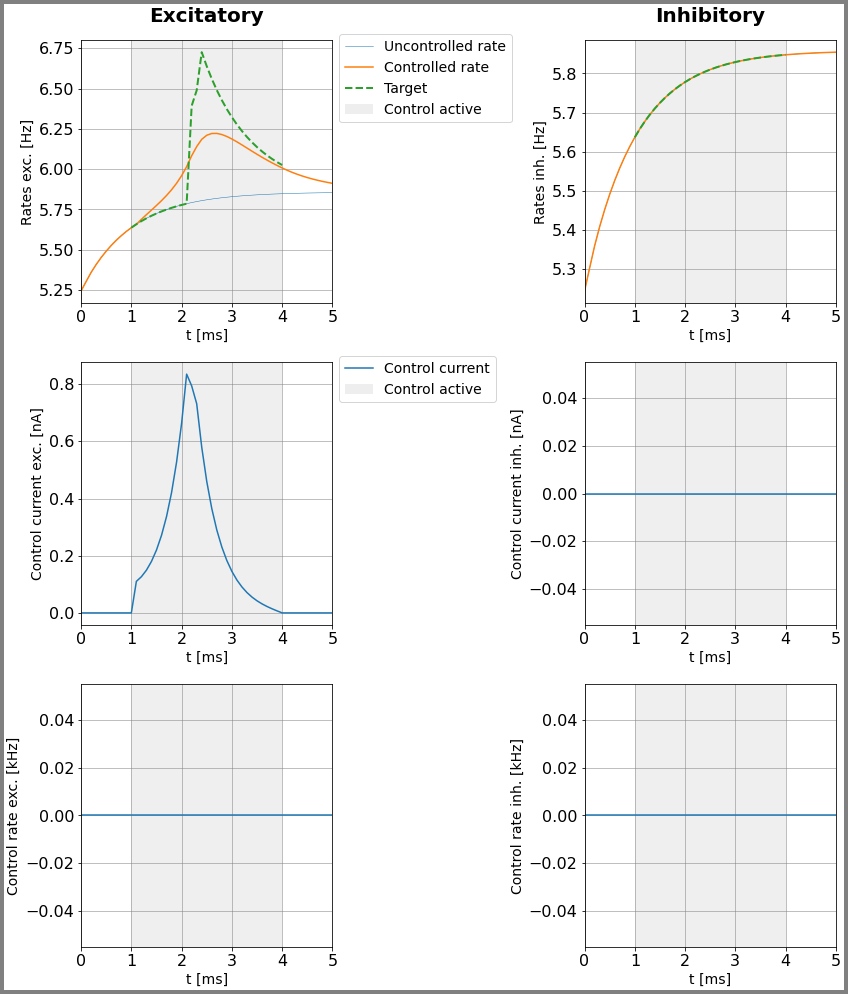

In [225]:
plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

In [226]:
cost.setParams(costparams[0], costparams[1], costparams[2])
setinitvars(high_state_vars)
max_it = 10
start_step = 1.
alg = "A2"
case = "test"
incl_step = 10
test_step = 1e-6

aln.params.duration = dur
control3 = aln.getZeroControl()
control4 = bestControlA[:,:,n_pre-1:-n_pre+1]
#control4[0,2,:20] = 0.
#control6 = bestControlA_A2[:,:,n_pre-1:-n_pre+1]

bestControlA_A2, bestStateA_A2, costA_A2, runtimeA_A2 = aln.A2(control4, target,
        max_iteration_ = max_it,  tolerance_ = tol, include_timestep_ = incl_step,
        start_step_ = start_step, test_step_ = test_step, max_control_ = max_cntrl,
        min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre,
        t_sim_post_ = dur_post, control_variables_ = control_ind, prec_variables_ = prec_var)

for i in range(1, len(costA_A2)):
    if costA_A2[i-1] < costA_A2[i]:
        print("ERROR ---------------- in index ", i)
        
print(bestControlA_A2[0,control_ind[0],:])

# 0.009869078053036093

ERROR:root:not implemented for less than full timesteps


set cost params
RUN  0 , total integrated cost:  0.14002288607782126
RUN  1 , total integrated cost:  0.14002287492733145
RUN  2 , total integrated cost:  0.14002287229072694
RUN  3 , total integrated cost:  0.14002287214316078
RUN  4 , total integrated cost:  0.14002287214110715


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  7 , total integrated cost:  0.1400228721409632
Improved over  7  iterations by  9.953271529639096e-06  percent.
Problem in initial value trasfer:  sigmae_f 0.4779313503021602 0.004595078362292733
Problem in initial value trasfer:  sigmai_f 0.30360581527540875 0.004595078362292733
Problem in initial value trasfer:  sigmae_f 0.4378879861071371 0.0037252878959236975
Problem in initial value trasfer:  sigmai_f 0.2881492394333913 0.004058126671082041
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.11029789
 0.12647121 0.14921485 0.17970398 0.21953919 0.2708787  0.33662548
 0.42054174 0.52741738 0.66300582 0.83466947 0.79373731 0.73140577
 0.5798381  0.45991836 0.36505516 0.28998588 0.23042437 0.183028
 0.14520597 0.1149527  0.09068332 0.07113176 0.05527849 0.04229605
 0.03150356 0.02233199 0.01429755 0.006982   0.         0.
 0.         0.         0.         0.         0.         0.
 0

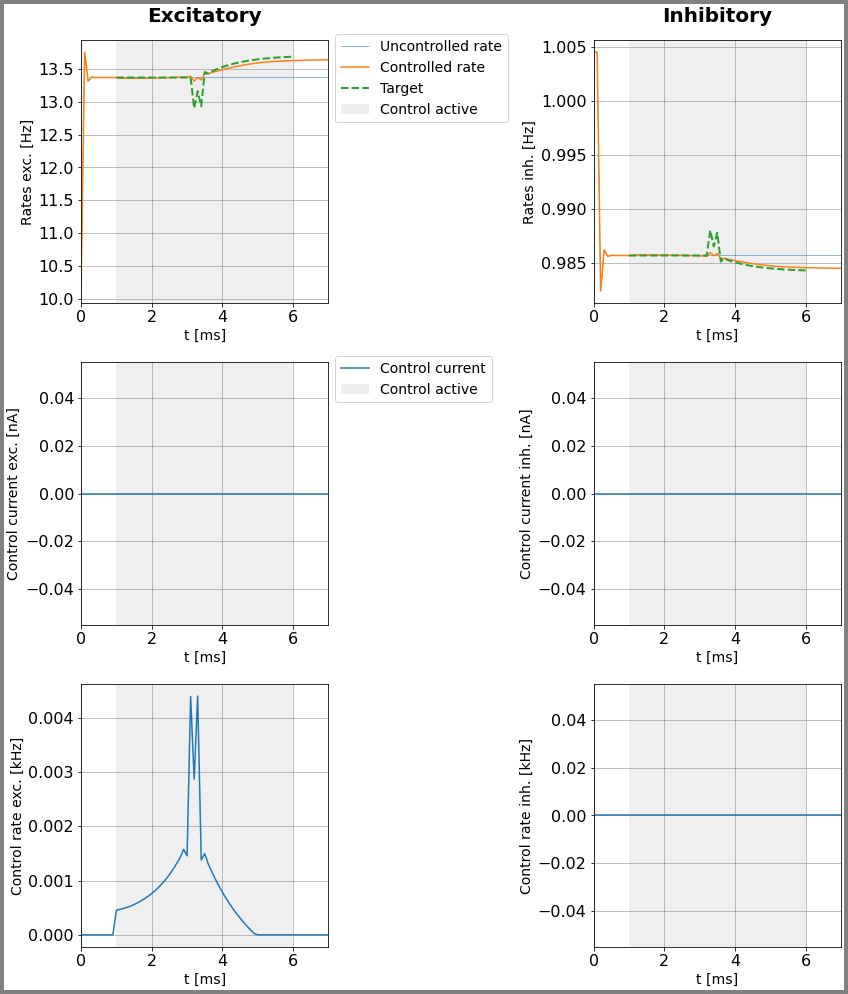

In [170]:
plotFunc.plot_control(aln, bestControlA_A2, dur, dur_pre, dur_post, high_state_vars, target, path)

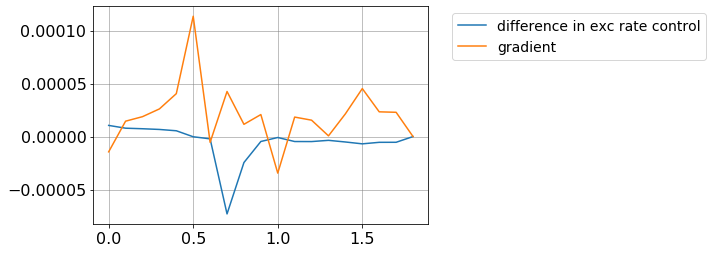

In [1219]:
diff = bestControlA_A2 - bestControlA
#diff[0,2,-2:] = 0.

#c_diff = costA_A2[6] - costA[3]
#print(c_diff)

t = np.arange(0,dur+0.1, 0.1)

#plt.plot(t, diff[0,0,:], label="difference in exc current control")
#plt.plot(t, diff[0,1,:], label="difference in inh current control")
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
#plt.grid()
#plt.show()

plt.plot(t, diff[0,2,n_pre-1:-n_post+1], label="difference in exc rate control")
#plt.plot(t, diff[0,3,n_pre:-n_post], label="difference in inh rate control")
plt.plot(t, grad[0,2,:], label="gradient")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

### Testcases

1. PRECISION ONLY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [x] 0 control, 1 precision measure, no delay
    - [x] 1 control, 0 precision measure, no delay
    - [] 2 control, 0 precision measure, no delay (slow to converge)
    - [] 2 control, 1 precision measure, no delay (slow to converge)

2. PRECISON + ENERGY + SPARSITY, NO DELAY
    - [x] 0 control, 0 precision measure, no delay
    - [x] 1 control, 1 precision measure, no delay
    - [] 0 control, 1 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, no delay (requires different weights, gradient vanishes, A2 performes differently and worse)
    - [x] 2 control, 0 precision measure, no delay
    - [] 2 control, 1 precision measure, no delay (requires different weights, zero control as output, gradient nonvanishing because on boundary. At higher weights, gradient vanishes)
    
3. PRECISION ONLY, DELAY
    - [x] 0 control, 0 precision measure, delay
    - [x] 1 control, 1 precision measure, delay
    - [] 0 control, 1 precision measure, delay (not in every case, could have several solutions)
    - [] 1 control, 0 precision measure, delay (not in every case, could have several solutions)
    - [x] 2 control, 0 precision measure, delay (sometimes slow convergence)
    - [x] 2 control, 1 precision measure, delay (sometimes slow to converge)

4. PRECISON + ENERGY + SPARSITY
    - [] 0 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 1 control, 1 precision measure, delay (gradient does not quite vanish)
    - [] 0 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 1 control, 0 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    - [] 2 control, 0 precision measure, delay (gradient does not quite vanish)
    - [] 2 control, 1 precision measure, delay (requires different weights, gradient does not quite vanish, A2 performes differently and worse)
    
The cost functional should always have more than one minimum. If the "direct" control (0,0; 1,1; 2,0; 3,1) is not applied, it is much more likely to end up in a local minimum, because there is no "dominant" contribution.

### What to take into account and don't forget
- if delay is present, always leave sufficient time steps before and after applying control
- allowing rates smaller than zero may cause trouble, because then same input can have different effect at different points of time
- is the fact that control enters computation at various points causing problems?
- if stuff of different orders of magnitude is competing, convergence is slow
- convergence in integration variables is much slower than in direct input
- make sure variables are in proper range: setting e.g. sigma to zero in time integration can cause problems
- the dynamics should not be explicitly dependent on time, otherwise adjoint formulation does not hold in this way
- apparently, also time-independent contributions mess up wiht the algorithm